# K-Analysis

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

In [29]:
# palette = {'mmd': 'lightsteelblue','l2': '#ffd7b5', 'l3': '#ffb38a', 'l4': '#ff9248', 'l5': '#ff6700'}
palette = {
    'mmd': '#a6cee3',   # soft blue
    'l2':  '#b2df8a',   # light green
    'l3':  '#fb9a99',   # soft red
    'l4':  '#fdbf6f',   # light orange
    'l5':  '#cab2d6'    # lavender
}

In [30]:
# Create a new DataFrame as a copy of the original
df_mmd_mmd2 = pd.read_csv('../evaluation/results.csv')

# Relabel the rules column in the new DataFrame
df_mmd_mmd2.loc[(df_mmd_mmd2['learner'] == 0) & (df_mmd_mmd2['rules'] == 'induction') & (df_mmd_mmd2['coverage'] == 0.6), 'rules'] = 'mmd'
df_mmd_mmd2.loc[(df_mmd_mmd2['learner'] == 1) & (df_mmd_mmd2['rules'] == 'induction') & (df_mmd_mmd2['coverage'] == 0.6), 'rules'] = 'l1'
df_mmd_mmd2.loc[(df_mmd_mmd2['learner'] == 2) & (df_mmd_mmd2['rules'] == 'induction') & (df_mmd_mmd2['coverage'] == 0.6), 'rules'] = 'l2'
df_mmd_mmd2.loc[(df_mmd_mmd2['learner'] == 3) & (df_mmd_mmd2['rules'] == 'induction') & (df_mmd_mmd2['coverage'] == 0.6), 'rules'] = 'l3'
df_mmd_mmd2.loc[(df_mmd_mmd2['learner'] == 4) & (df_mmd_mmd2['rules'] == 'induction') & (df_mmd_mmd2['coverage'] == 0.6), 'rules'] = 'l4'
df_mmd_mmd2.loc[(df_mmd_mmd2['learner'] == 6) & (df_mmd_mmd2['rules'] == 'induction') & (df_mmd_mmd2['coverage'] == 0.6), 'rules'] = 'l5'

# Filter rows where rules is either 'induction' or 'mmd2'
df_mmd_mmd2 = df_mmd_mmd2[df_mmd_mmd2['rules'].isin(['mmd','l1', 'l2', 'l3', 'l4', 'l5'])]

In [31]:
df_mmd_mmd2['fscore'] = 2 * (df_mmd_mmd2['precision_with'] * df_mmd_mmd2['recall_with']) / (df_mmd_mmd2['precision_with'] + df_mmd_mmd2['recall_with'])

In [32]:
#df_mmd_mmd2

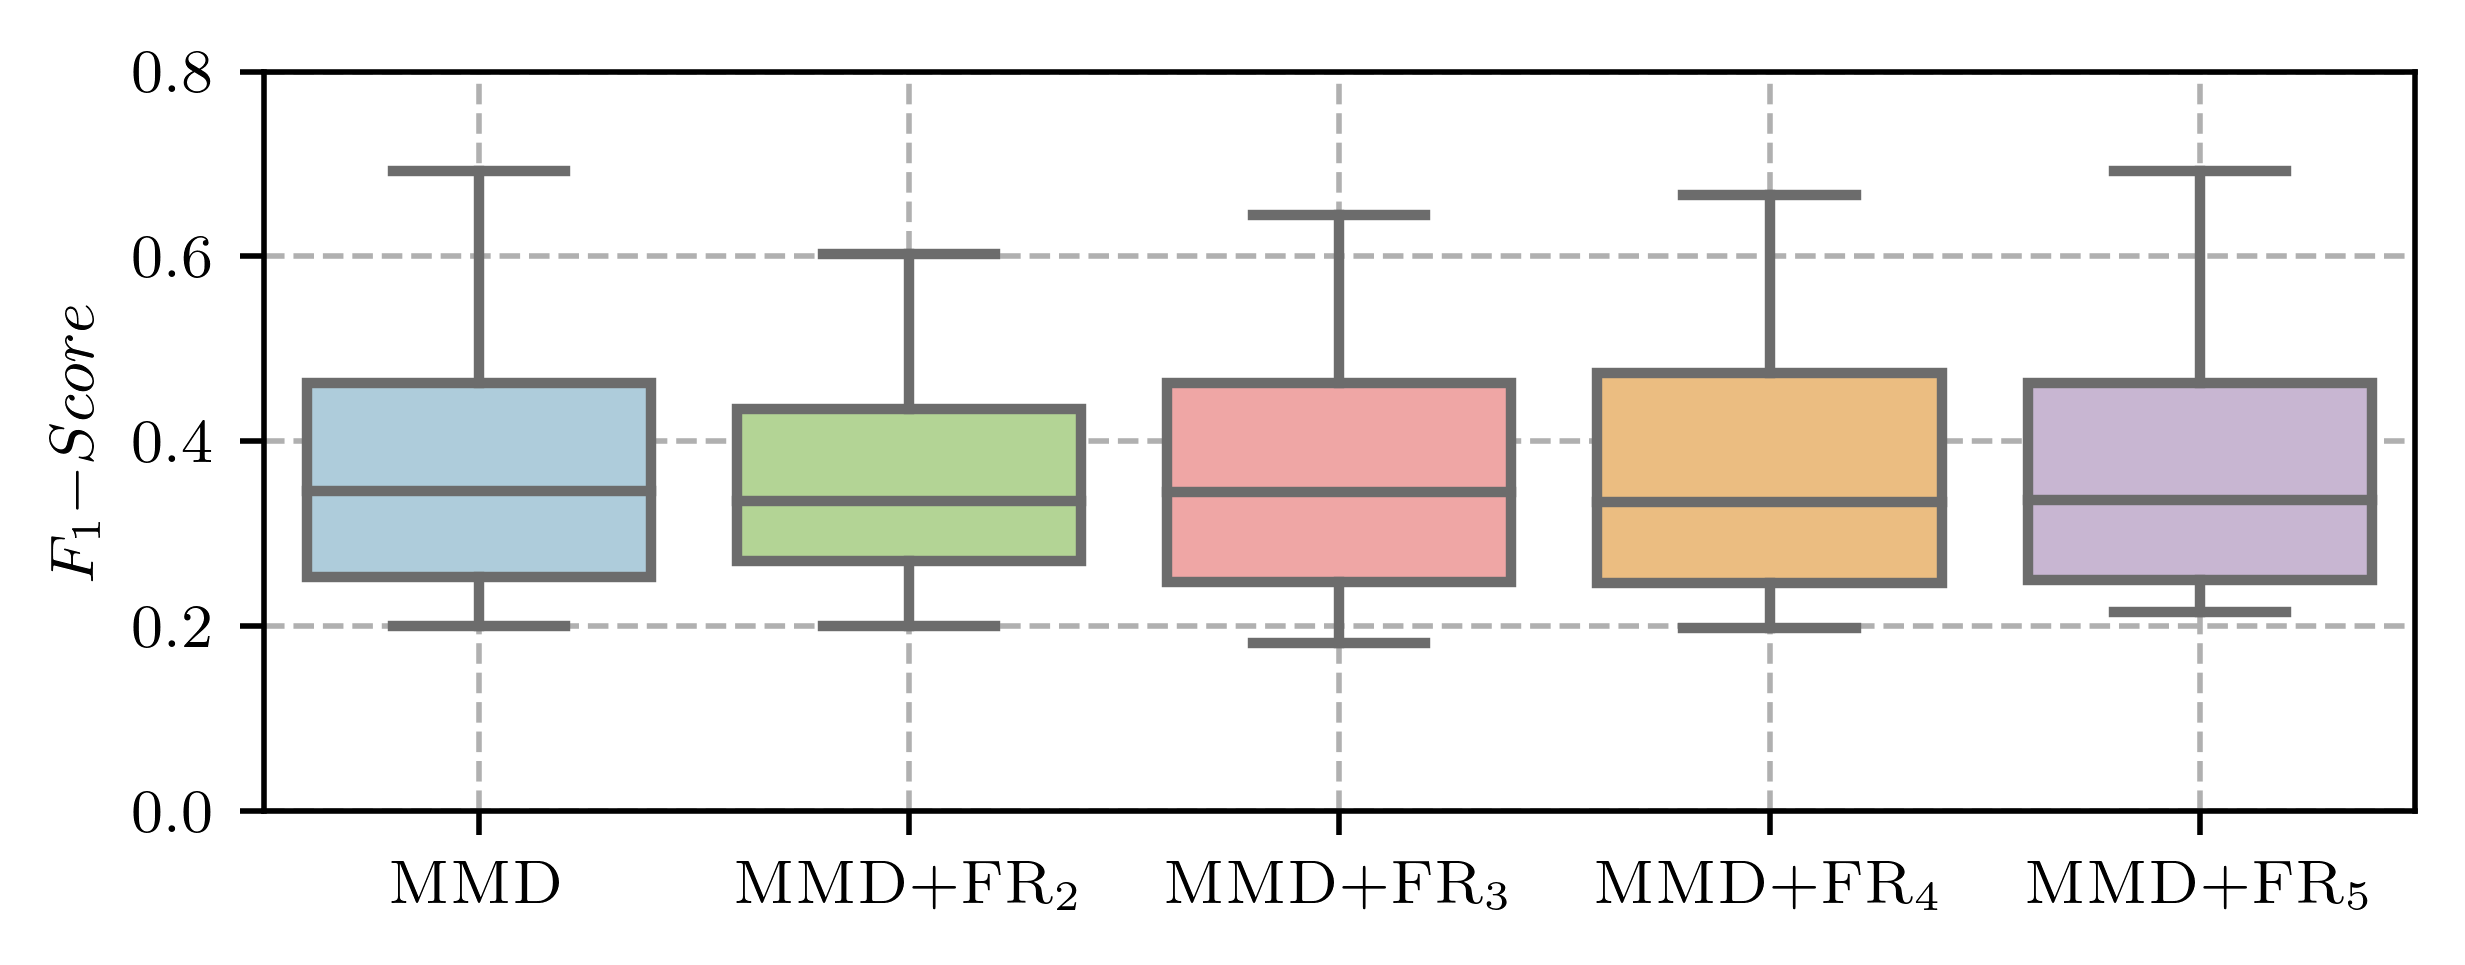

In [41]:
# Create the box plot
plt.figure(figsize=(5, 2), dpi=500)
plt.rcParams['text.usetex'] = True
plt.rc('axes', axisbelow=True)
plt.rcParams.update({'font.size': 9})

#sns.boxplot(x='blackbox', y='time_with', hue='rules', data=df_mmd_mmd2, palette=palette)
sns.boxplot(x='rules', y='fscore', data=df_mmd_mmd2, palette=palette)
# plt.title('F-score Distribution by Subject for MMD and Our Approach')
plt.ylabel(r'$F_1{-}Score$')
plt.xlabel(r'')
plt.yticks(np.arange(0, 0.81, 0.2))
plt.grid(axis="x", linestyle='--')
plt.grid(axis="y", linestyle='--')
plt.xticks(ticks=[0,1,2,3,4], labels= [])
first_patch = mpatches.Patch(ec="black" ,facecolor='lightsteelblue')

#second_patch = mpatches.Patch(ec="black" ,facecolor='floralwhite')
third_patch = mpatches.Patch(ec="black" ,facecolor='#EDC9AF')
fourth_patch = mpatches.Patch(ec="black" ,facecolor='#FFB347')
fith_patch = mpatches.Patch(ec="black" ,facecolor='navajowhite')
sixth_patch = mpatches.Patch(ec="black" ,facecolor='burlywood')

#plt.xticks(ticks=[0,1,2,3,4], labels=[r'\scshape{MMD}', r'\scshape{k=2}', r'\scshape{k=3}', r'\scshape{k=4}', r'\scshape{k=5}'],)
r'\scshape{MMD+FR}$_{2}$'
plt.xticks(ticks=[0,1,2,3,4], labels=[r'\scshape{MMD}', r'\scshape{MMD+FR}$_{2}$', r'\scshape{MMD+FR}$_{3}$', r'\scshape{MMD+FR}$_{4}$', r'\scshape{MMD+FR}$_{5}$'],)
# plt.legend(handles=[first_patch, second_patch])
plt.tight_layout()
plt.savefig('./k-fscore.pdf')

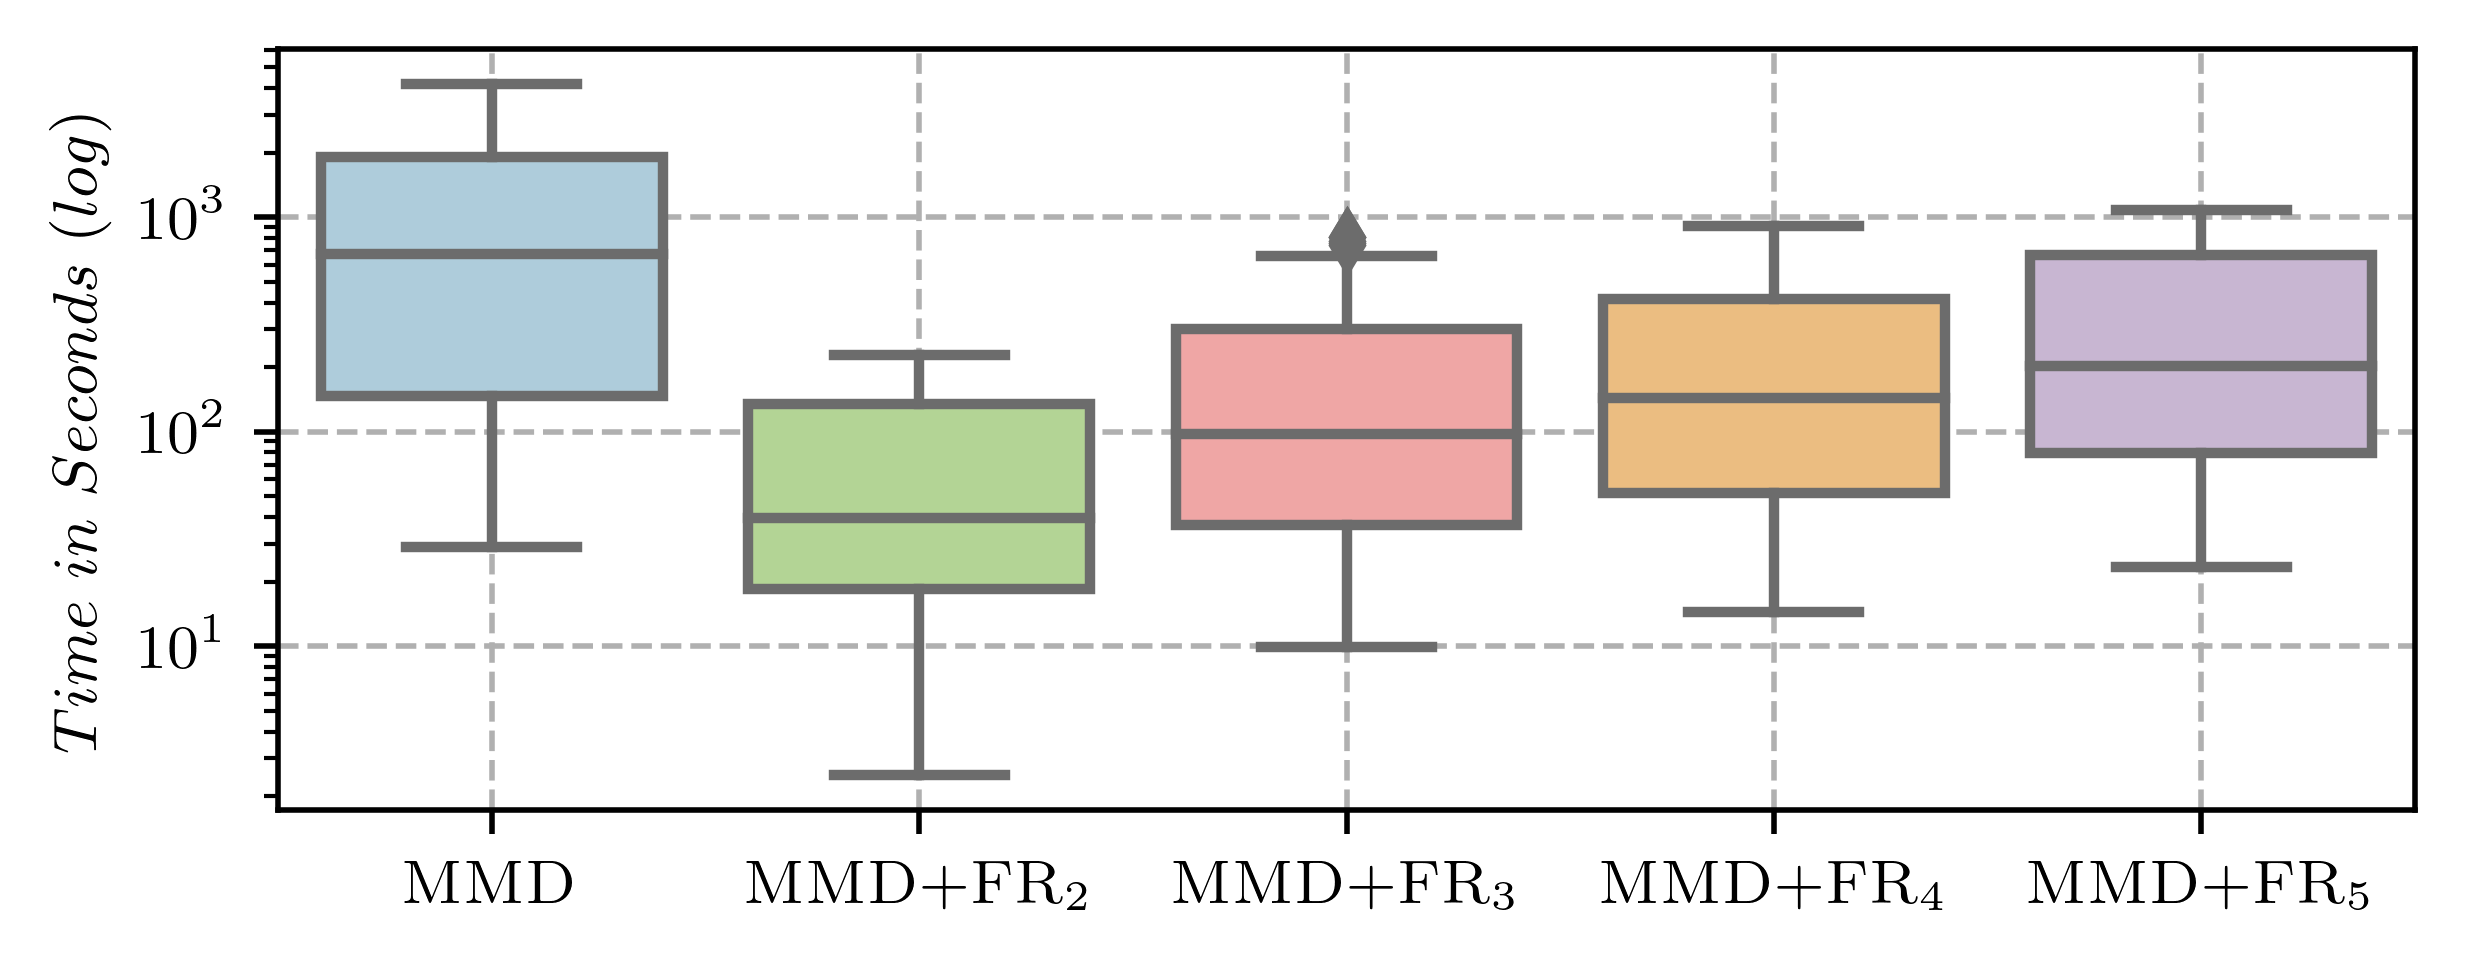

In [44]:
# Create the box plot
plt.figure(figsize=(5, 2), dpi=500)
plt.rcParams['text.usetex'] = True
plt.rc('axes', axisbelow=True)
plt.rcParams.update({'font.size': 9})

#sns.boxplot(x='blackbox', y='time_with', hue='rules', data=df_mmd_mmd2, palette=palette)
sns.boxplot(x='rules', y='time_with', data=df_mmd_mmd2, palette=palette)
# plt.title('F-score Distribution by Subject for MMD and Our Approach')
plt.grid(axis="y", linestyle='--',)
plt.grid(axis="x", linestyle='--',which='both')
plt.ylabel(r'$F-Score$')
plt.xlabel('')
plt.ylabel(r'$Time$ $in$ $Seconds$ $(log)$')
plt.yscale('log')
#plt.xticks(rotation=45)

#plt.xticks(ticks=[0,1,2,3,4,], labels=[r'\scshape{MMD}', r'\scshape{MMD+FR}$_{k=2}$', r'\scshape{MMD+FR}$_{k=3}$', r'\scshape{MMD+FR}$_{k=4}$', r'\scshape{MMD+FR}$_{k=5}$'],)
#plt.xticks(ticks=[0,1,2,3,4], labels=[r'\scshape{MMD}', r'\scshape{k=2}', r'\scshape{k=3}', r'\scshape{k=4}', r'\scshape{k=5}'],)
plt.xticks(ticks=[0,1,2,3,4], labels=[r'\scshape{MMD}', r'\scshape{MMD+FR}$_{2}$', r'\scshape{MMD+FR}$_{3}$', r'\scshape{MMD+FR}$_{4}$', r'\scshape{MMD+FR}$_{5}$'],)
first_patch = mpatches.Patch(ec="black" ,facecolor='lightsteelblue')

second_patch = mpatches.Patch(ec="black" ,facecolor='floralwhite')
third_patch = mpatches.Patch(ec="black" ,facecolor='oldlace')
fourth_patch = mpatches.Patch(ec="black" ,facecolor='papayawhip')
fith_patch = mpatches.Patch(ec="black" ,facecolor='navajowhite')
sixth_patch = mpatches.Patch(ec="black" ,facecolor='burlywood')

#plt.legend(loc=4,title=r'\textbf{Approach}', labels=[r'\scshape{MMD}', r'\scshape{MMD+FR}$_{k=2}$', r'\scshape{MMD+FR}$_{k=3}$', r'\scshape{MMD+FR}$_{k=4}$', r'\scshape{MMD+FR}$_{k=5}$'], handles=[first_patch, third_patch, fourth_patch, fith_patch, sixth_patch])
# plt.legend(handles=[first_patch, second_patch])
plt.tight_layout()
plt.savefig('./k-time.pdf')

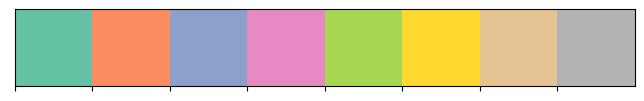

In [20]:
sns.palplot(sns.color_palette("Set2"))
